In [2]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('/content/drive/MyDrive/iris.csv')
print(df.shape)
df.head()

Mounted at /content/drive
(150, 5)


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
df_iris = pd.read_csv('/content/drive/MyDrive/iris.csv')
print(df_iris.shape)
print(df_iris['species'].value_counts())
df_iris.head()

(150, 5)
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df_iris.drop('species', axis=1)   # 4 features
y = df_iris['species']                 # 3 classes

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=101
)

scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test  = scaler.transform(X_test)

Accuracy: 0.9736842105263158


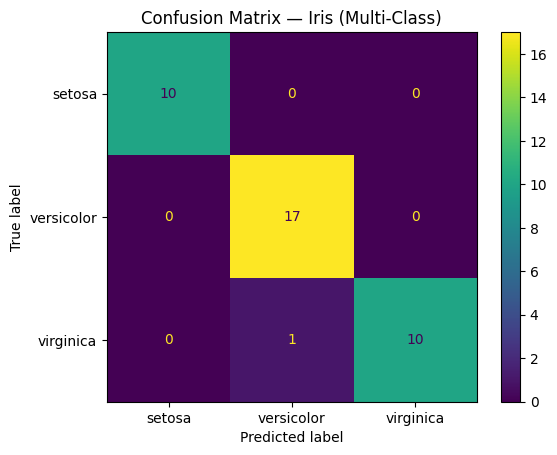

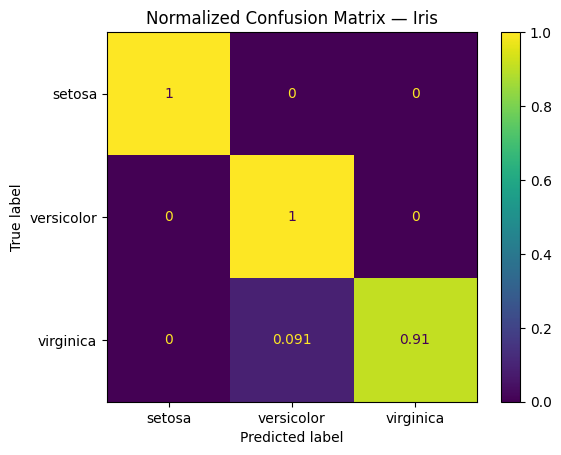

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.94      1.00      0.97        17
   virginica       1.00      0.91      0.95        11

    accuracy                           0.97        38
   macro avg       0.98      0.97      0.97        38
weighted avg       0.98      0.97      0.97        38



In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

log_model = LogisticRegression()
log_model.fit(scaled_X_train, y_train)

y_pred = log_model.predict(scaled_X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix (3x3 for 3 classes)
ConfusionMatrixDisplay.from_estimator(log_model, scaled_X_test, y_test)
plt.title("Confusion Matrix — Iris (Multi-Class)")
plt.show()

ConfusionMatrixDisplay.from_estimator(log_model, scaled_X_test, y_test, normalize='true')
plt.title("Normalized Confusion Matrix — Iris")
plt.show()

print(classification_report(y_test, y_pred))